# 01 - El dataset, descomposición y estacionariedad

**Módulo 3 - Series de Tiempo | ML Avanzado**

Una *serie de tiempo* es una secuencia de observaciones ordenadas en el tiempo,
$\{y_t\}_{t=1}^{T}$. A diferencia de los datos tabulares i.i.d., **el orden
temporal lleva información**: las observaciones cercanas están correlacionadas,
y esa correlación es justo lo que explotaremos para pronosticar.

En este notebook:

1. Conocemos el **dataset del módulo** (consumo eléctrico de un hogar, UCI #235).
2. Los componentes de una serie; modelos **aditivos vs multiplicativos**.
3. Descomposición clásica (`seasonal_decompose`) y **STL**.
4. **Estacionariedad**: estadísticos móviles, ACF/PACF y prueba ADF.
5. **Pronósticos baseline** + las **métricas** (MSE, RMSE, MAE, MAPE, sMAPE)
   que usaremos en todo el módulo, registradas en **MLflow**.

In [16]:
import os, sys, warnings
warnings.filterwarnings("ignore")

# Hacemos importable utils/ tanto si el notebook corre desde notebooks/ como
# desde la raíz del repositorio.
_here = os.getcwd()
for cand in (os.path.join(_here, "..", "utils"), os.path.join(_here, "utils"),
             os.path.join(_here, "..", "..", "module3-time-series", "utils")):
    cand = os.path.abspath(cand)
    if os.path.isdir(cand) and cand not in sys.path:
        sys.path.insert(0, cand)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
from mlflow_helpers import setup_mlflow, log_and_register, register_best_run

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True
np.random.seed(42)
print("Versión de MLflow:", mlflow.__version__)

Versión de MLflow: 3.14.0


## El dataset: consumo eléctrico de un hogar (UCI #235)

Usaremos en **todo el módulo** el dataset
[Individual Household Electric Power Consumption](https://archive.ics.uci.edu/dataset/235/individual+household+electric+power+consumption)
del repositorio de UCI: mediciones eléctricas de una vivienda en Sceaux
(Francia) tomadas **cada minuto** entre diciembre de 2006 y noviembre de 2010
(~2 millones de filas, ~1.25% de minutos faltantes marcados con `?`).

Trabajaremos con la **potencia activa global** (`Global_active_power`, en
kilovatios) agregada a dos resoluciones:

- **`daily`** — promedio diario (≈1,440 días): la serie principal para
  pronóstico.
- **`hourly`** — promedio horario (≈34,500 horas): la usaremos para perfiles
  de carga intradía.

La primera ejecución descarga el zip (~20 MB) y deja un caché CSV en
`../data/`; las siguientes leen el caché. Los huecos (incluidos un par de
cortes de varios días) se rellenan con interpolación temporal. Si no hay
internet, se genera un **respaldo sintético** con estacionalidad semanal y
anual para que el notebook siga corriendo.

In [2]:
# ---------------------------------------------------------------------------
# Carga del dataset UCI #235 (con caché local y respaldo sintético offline)
# ---------------------------------------------------------------------------
import io, zipfile, urllib.request

UCI_ZIP_URL = ("https://archive.ics.uci.edu/static/public/235/"
               "individual+household+electric+power+consumption.zip")

def _data_dir():
    for cand in ("../data", "data", "module3-time-series/data"):
        cand = os.path.abspath(cand)
        if os.path.isdir(cand):
            return cand
    cand = os.path.abspath("../data")
    os.makedirs(cand, exist_ok=True)
    return cand

DATA_DIR = _data_dir()
DAILY_CSV = os.path.join(DATA_DIR, "household_power_daily.csv")
HOURLY_CSV = os.path.join(DATA_DIR, "household_power_hourly.csv")

def load_household_power():
    """Devuelve (daily, hourly): potencia activa global media, en kW."""
    if os.path.isfile(DAILY_CSV) and os.path.isfile(HOURLY_CSV):
        daily = pd.read_csv(DAILY_CSV, index_col=0, parse_dates=True).iloc[:, 0]
        hourly = pd.read_csv(HOURLY_CSV, index_col=0, parse_dates=True).iloc[:, 0]
        return daily.asfreq("D"), hourly.asfreq("h")

    print("Descargando el dataset UCI #235 (~20 MB)...")
    raw = urllib.request.urlopen(UCI_ZIP_URL, timeout=180).read()
    with zipfile.ZipFile(io.BytesIO(raw)) as zf:
        with zf.open("household_power_consumption.txt") as fh:
            df = pd.read_csv(fh, sep=";", na_values=["?"], low_memory=False,
                             usecols=["Date", "Time", "Global_active_power"])
    ts = pd.to_datetime(df["Date"] + " " + df["Time"],
                        format="%d/%m/%Y %H:%M:%S")
    power = pd.Series(df["Global_active_power"].astype(float).to_numpy(),
                      index=ts, name="global_active_power_kw").sort_index()

    # Agregamos y rellenamos huecos por interpolación temporal (~1.25% de
    # minutos faltantes + un par de cortes de varios días).
    daily = power.resample("D").mean().interpolate(method="time")
    hourly = power.resample("h").mean().interpolate(method="time")
    daily = daily.iloc[1:-1]                       # primer/último día parciales
    hourly = hourly.loc[daily.index.min():
                        daily.index.max() + pd.Timedelta(hours=23)]
    daily.to_frame().to_csv(DAILY_CSV)
    hourly.to_frame().to_csv(HOURLY_CSV)
    return daily.asfreq("D"), hourly.asfreq("h")

try:
    daily, hourly = load_household_power()
    print(f"daily : {daily.index.min().date()} .. {daily.index.max().date()} "
          f"(n={len(daily)})")
    print(f"hourly: n={len(hourly)}")
except Exception as e:
    print("No se pudo descargar el dataset:", repr(e))
    print("Usando RESPALDO SINTÉTICO (estacionalidad semanal + anual).")
    rng = np.random.default_rng(7)
    idx = pd.date_range("2006-12-17", "2010-11-25", freq="D")
    t = np.arange(len(idx))
    daily = pd.Series(
        1.1
        + 0.35 * np.cos(2 * np.pi * (t - 20) / 365.25)   # invierno alto
        + 0.10 * (idx.dayofweek >= 5)                     # fin de semana
        + rng.normal(0, 0.12, len(idx)),
        index=idx, name="global_active_power_kw").clip(lower=0.1).asfreq("D")
    hidx = pd.date_range(idx.min(), idx.max() + pd.Timedelta(hours=23), freq="h")
    hh = hidx.hour.to_numpy()
    base = daily.reindex(pd.DatetimeIndex(hidx.date)).to_numpy()
    profile = 0.6 + 0.35 * np.sin(2 * np.pi * (hh - 14) / 24) \
              + 0.25 * ((hh >= 18) & (hh <= 22))
    hourly = pd.Series(base * profile + rng.normal(0, 0.05, len(hidx)),
                       index=hidx, name=daily.name).clip(lower=0.05).asfreq("h")

daily : 2006-12-17 .. 2010-11-25 (n=1440)
hourly: n=34560


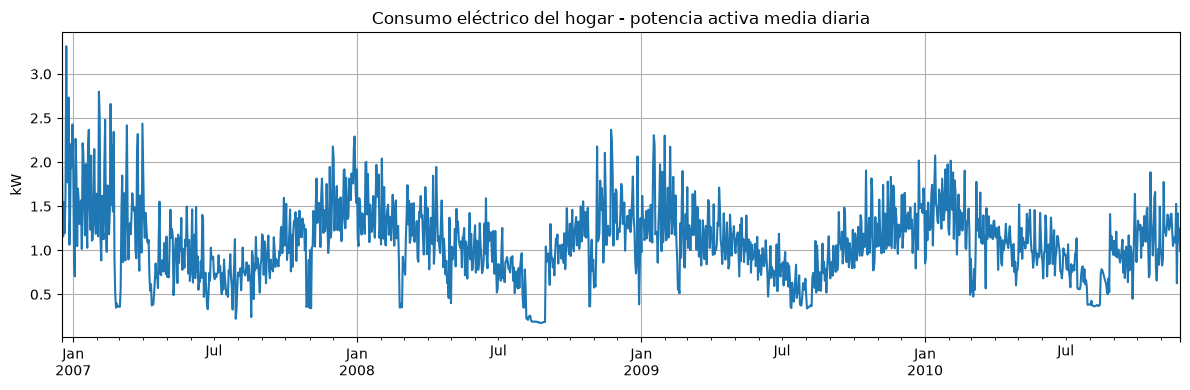

In [3]:
ax = daily.plot(title="Consumo eléctrico del hogar - potencia activa media diaria")
ax.set_ylabel("kW")
plt.tight_layout(); plt.show()

# Dos patrones saltan a la vista:
#  - ESTACIONALIDAD ANUAL: inviernos altos (calefacción), veranos bajos
#    (¡y los huecos de vacaciones de agosto!).
#  - Mucho ruido de día a día: el comportamiento humano es irregular.

### Estacionalidad a varias escalas

El consumo de un hogar tiene estructura en **tres** escalas temporales:
anual (clima), semanal (rutinas laborales vs fin de semana) e intradía
(mañana/noche). Veámoslas por separado.

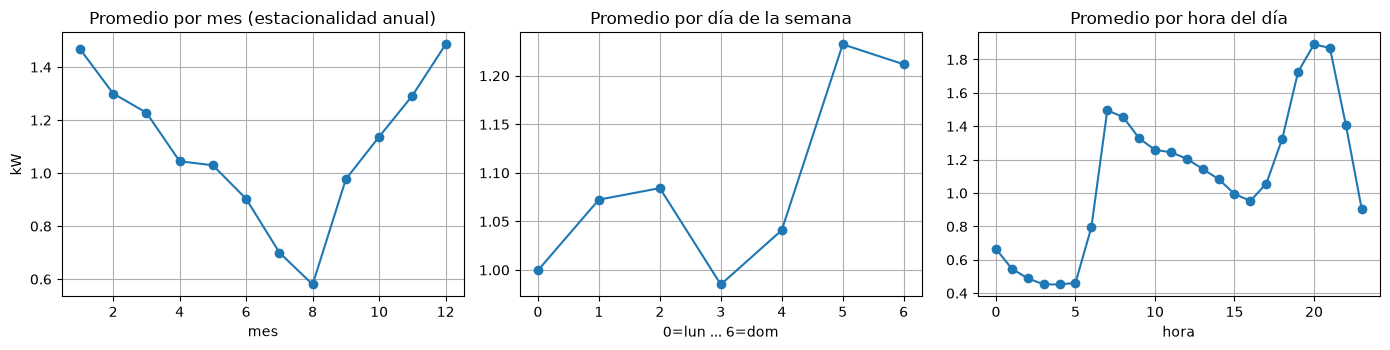

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))

# anual: promedio por mes
daily.groupby(daily.index.month).mean().plot(ax=axes[0], marker="o")
axes[0].set_title("Promedio por mes (estacionalidad anual)")
axes[0].set_xlabel("mes"); axes[0].set_ylabel("kW")

# semanal: promedio por día de la semana
daily.groupby(daily.index.dayofweek).mean().plot(ax=axes[1], marker="o")
axes[1].set_title("Promedio por día de la semana")
axes[1].set_xlabel("0=lun ... 6=dom")

# intradía: promedio por hora (serie horaria)
hourly.groupby(hourly.index.hour).mean().plot(ax=axes[2], marker="o")
axes[2].set_title("Promedio por hora del día")
axes[2].set_xlabel("hora")

plt.tight_layout(); plt.show()

## 1. Los componentes de una serie de tiempo

Un modelo conceptual muy usado descompone la serie observada en cuatro partes:

$$
y_t = T_t + S_t + C_t + R_t
$$

- **Tendencia $T_t$** — la dirección de largo plazo.
- **Estacionalidad $S_t$** — un patrón que se repite con periodo *fijo y
  conocido* $m$ (aquí: $m=7$ días para la semana, $m\approx365$ para el año).
- **Ciclo $C_t$** — fluctuaciones largas **sin periodo fijo** (ciclos
  económicos); en la práctica se absorbe en la tendencia.
- **Residual $R_t$** — lo que queda; idealmente ruido blanco.

### ¿Aditivo o multiplicativo?

**Aditivo** — la amplitud estacional es constante sin importar el nivel:
$y_t = T_t + S_t + R_t$.

**Multiplicativo** — la amplitud **escala con el nivel** (picos cada vez más
grandes): $y_t = T_t \times S_t \times R_t$. Truco clave: en escala
**logarítmica** se vuelve aditivo, porque
$\log y_t = \log T_t + \log S_t + \log R_t$.

En nuestro dataset la amplitud del ciclo anual es razonablemente estable (no
crece con los años — el hogar no consume cada vez más), así que trabajaremos
con el modelo **aditivo**. Compara esto con la clásica serie *AirPassengers*,
el ejemplo canónico multiplicativo.

## 2. Descomposición clásica (`seasonal_decompose`)

`statsmodels` implementa la descomposición clásica basada en promedios
móviles: (1) estima $\hat T_t$ con un promedio móvil centrado de longitud $m$;
(2) quita la tendencia; (3) estima $\hat S_t$ promediando por posición dentro
del periodo; (4) el resto es $\hat R_t$.

Para verla con claridad suavizamos primero a **promedio semanal** y
descomponemos el ciclo anual ($m = 52$ semanas).

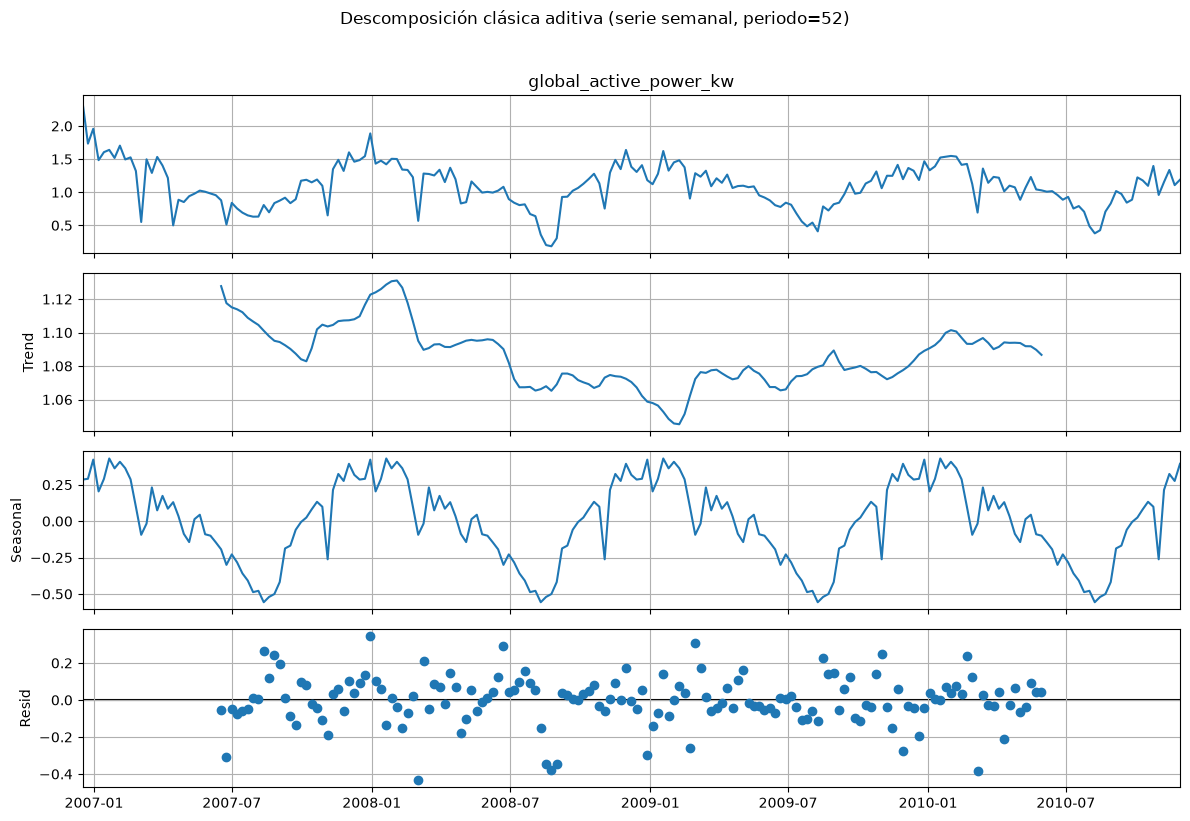

In [17]:
from statsmodels.tsa.seasonal import seasonal_decompose

weekly = daily.resample("W").mean()
dec = seasonal_decompose(weekly, model="additive", period=52)
fig = dec.plot()
fig.set_size_inches(12, 8)
fig.suptitle("Descomposición clásica aditiva (serie semanal, periodo=52)", y=1.02)
plt.tight_layout(); plt.show()

### Limitaciones de la descomposición clásica

- La tendencia queda **indefinida en los bordes** (se pierde media ventana en
  cada extremo — mira los NaN al inicio/fin del panel *Trend*).
- El componente estacional está forzado a ser **idéntico cada periodo**.
- **No es robusta** a atípicos (un corte de luz contamina la tendencia).

## 3. Descomposición STL

**STL** (*Seasonal-Trend decomposition using LOESS*, Cleveland et al. 1990)
ajusta suavizadores LOESS en un bucle interno/externo. Siempre es **aditiva**
(para efectos multiplicativos: aplicar sobre $\log y_t$). Ventajas:

- El componente estacional **puede evolucionar** en el tiempo (`seasonal`).
- Suavidad de la tendencia **ajustable** (`trend`).
- **Robusta** a atípicos con `robust=True` (pesos que amortiguan residuos
  grandes — ideal con los huecos/vacaciones de este hogar).

Descomponemos la serie **diaria** con periodo semanal $m=7$: la "tendencia"
de STL absorberá el ciclo anual (que para $m=7$ es de baja frecuencia).

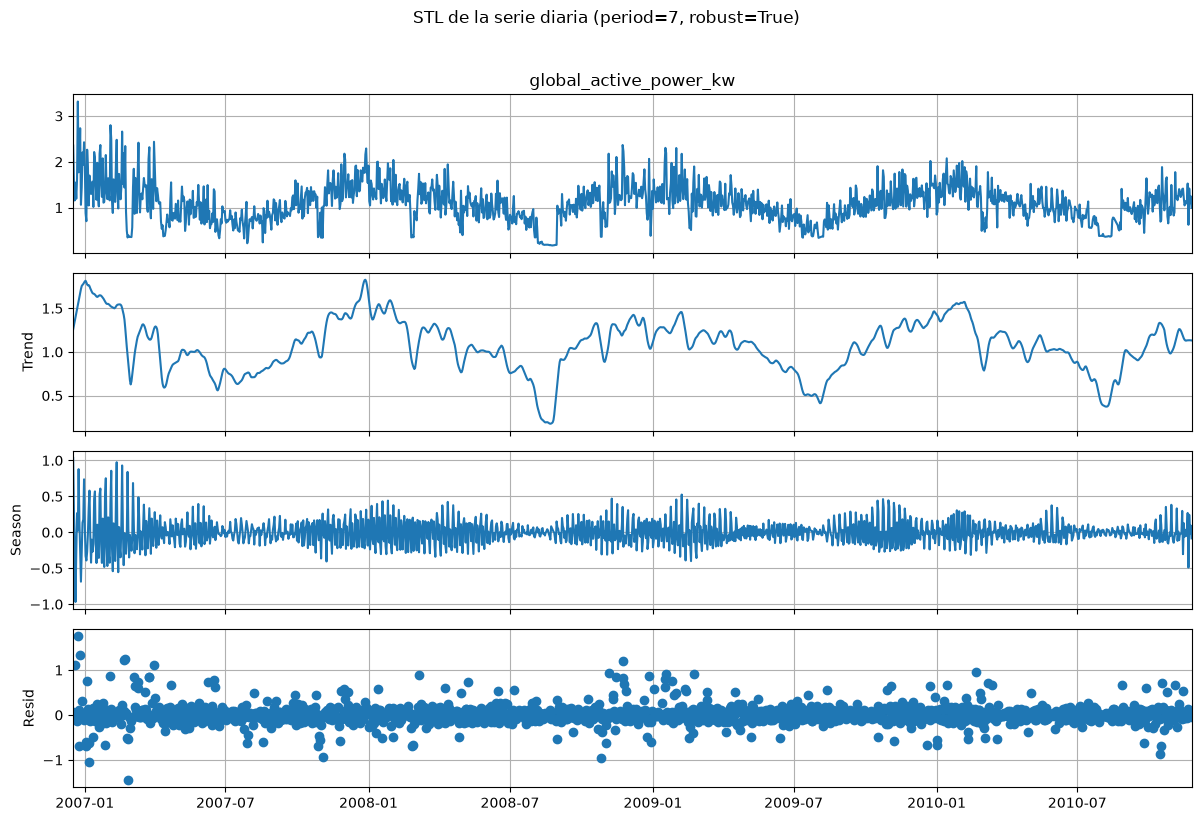

Desviación estándar del residual: 0.2294


In [18]:
from statsmodels.tsa.seasonal import STL

stl = STL(daily, period=7, robust=True)
res = stl.fit()
fig = res.plot()
fig.set_size_inches(12, 8)
fig.suptitle("STL de la serie diaria (period=7, robust=True)", y=1.02)
plt.tight_layout(); plt.show()

print("Desviación estándar del residual:", round(res.resid.std(), 4))

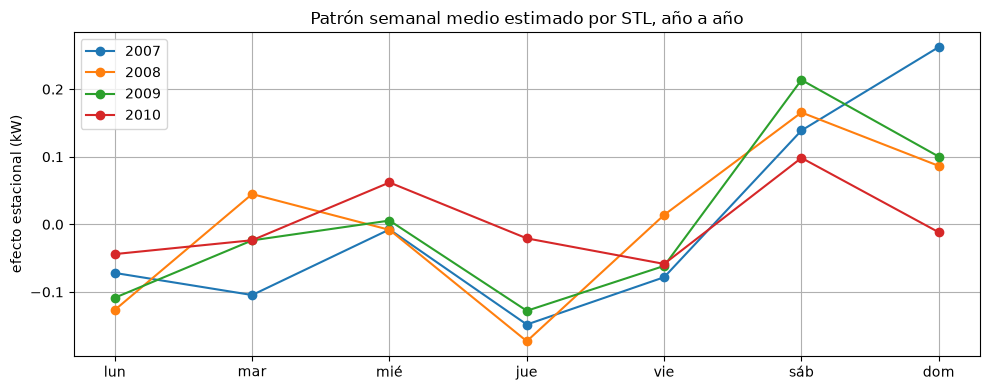

In [19]:
# El componente estacional semanal de STL puede derivar con el tiempo:
seasonal = res.seasonal
fig, ax = plt.subplots(figsize=(10, 4))
for year in [2007, 2008, 2009, 2010]:
    s = seasonal[seasonal.index.year == year]
    ax.plot(s.groupby(s.index.dayofweek).mean().values, marker="o", label=str(year))
ax.set_xticks(range(7), ["lun", "mar", "mié", "jue", "vie", "sáb", "dom"])
ax.set_ylabel("efecto estacional (kW)")
ax.set_title("Patrón semanal medio estimado por STL, año a año")
ax.legend(); plt.tight_layout(); plt.show()

## 4. Estacionariedad

Una serie es **(débilmente) estacionaria** si sus propiedades estadísticas no
cambian con el tiempo:

$$
\mathbb{E}[y_t] = \mu, \qquad
\operatorname{Var}(y_t) = \sigma^2, \qquad
\operatorname{Cov}(y_t, y_{t+k}) = \gamma(k) \ \text{depende solo de } k .
$$

¿Por qué importa? La teoría clásica (AR, MA, ARMA — notebook 02) **supone
estacionariedad**. Tendencia y estacionalidad la violan; las quitamos con
**diferenciación** — con el operador de rezago $L y_t = y_{t-1}$: primera
diferencia $(1-L)$, diferencia estacional $(1-L^m)$ — modelamos la versión
estacionaria e invertimos al final.

Diagnóstico en tres frentes: estadísticos móviles, ACF/PACF y la prueba ADF.

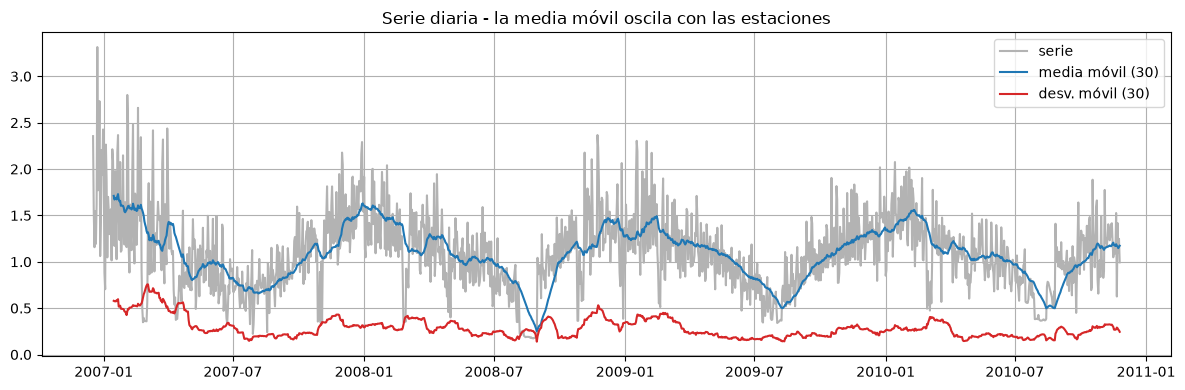

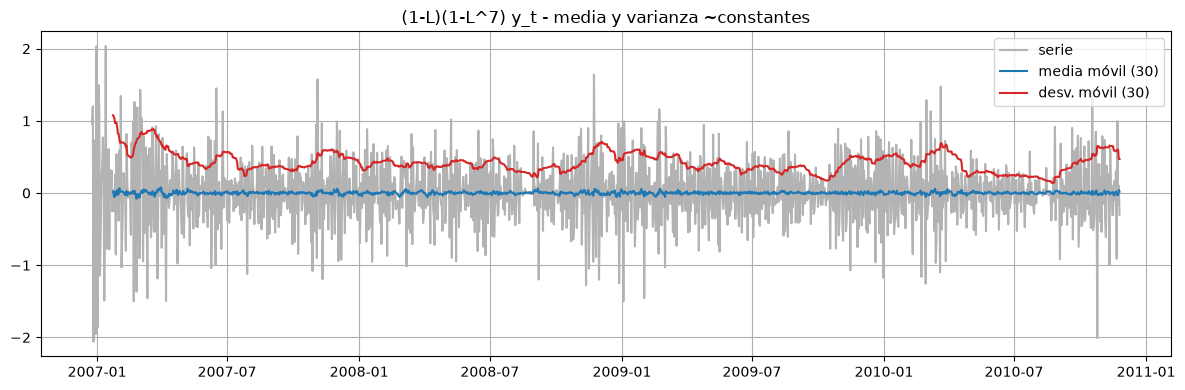

In [20]:
def plot_rolling(series, window, title=""):
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(series, color="0.7", label="serie")
    ax.plot(series.rolling(window).mean(), color="C0", label=f"media móvil ({window})")
    ax.plot(series.rolling(window).std(), color="C3", label=f"desv. móvil ({window})")
    ax.set_title(title); ax.legend()
    plt.tight_layout(); plt.show()

plot_rolling(daily, 30, "Serie diaria - la media móvil oscila con las estaciones")

# diferencia estacional semanal + primera diferencia
stationary = daily.diff(1).diff(7).dropna()   # (1-L)(1-L^7) y_t
plot_rolling(stationary, 30, "(1-L)(1-L^7) y_t - media y varianza ~constantes")

### ACF y PACF

- La **ACF** $\rho(k) = \gamma(k)/\gamma(0)$ mide la correlación entre $y_t$ y
  $y_{t-k}$, *incluyendo* los efectos indirectos vía rezagos intermedios.
- La **PACF** mide esa correlación **tras eliminar** la influencia de los
  rezagos $1..k-1$.

Señal delatora: en una serie no estacionaria la ACF decae *muy lento*. En el
notebook 02 usaremos estas gráficas para elegir los órdenes de un ARIMA.

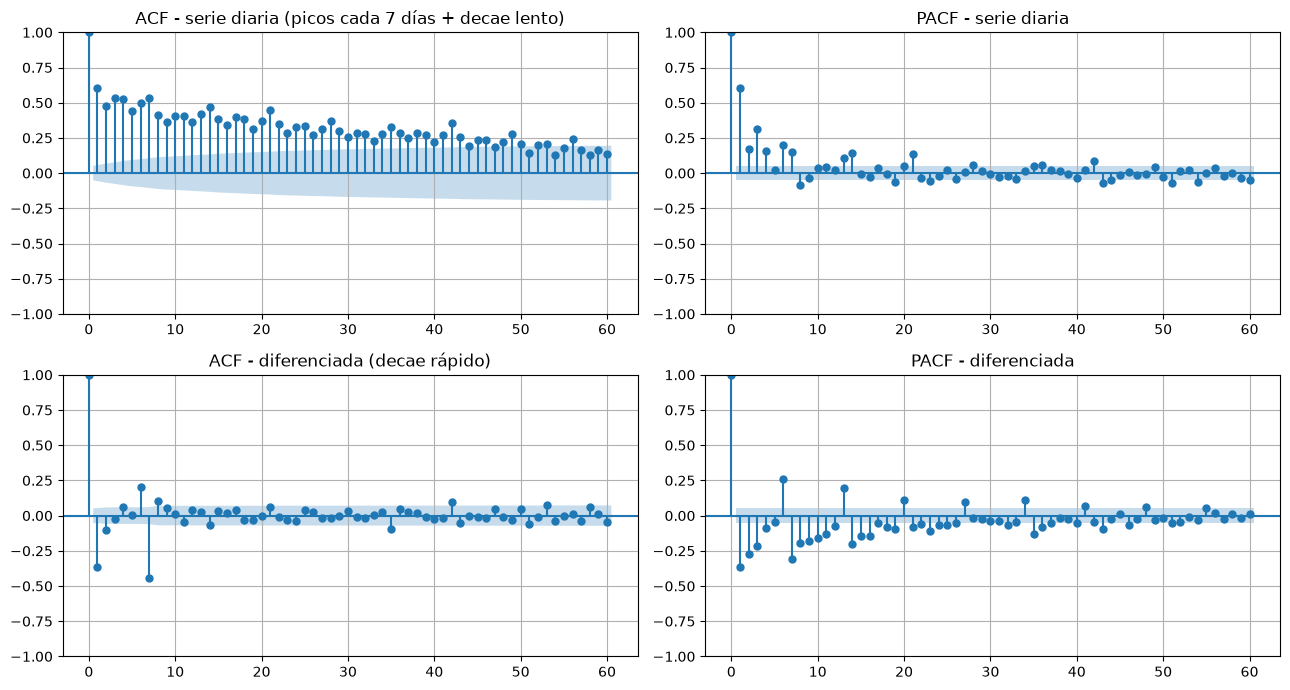

In [21]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
plot_acf(daily, lags=60, ax=axes[0, 0])
axes[0, 0].set_title("ACF - serie diaria (picos cada 7 días + decae lento)")
plot_pacf(daily, lags=60, ax=axes[0, 1], method="ywm")
axes[0, 1].set_title("PACF - serie diaria")
plot_acf(stationary, lags=60, ax=axes[1, 0])
axes[1, 0].set_title("ACF - diferenciada (decae rápido)")
plot_pacf(stationary, lags=60, ax=axes[1, 1], method="ywm")
axes[1, 1].set_title("PACF - diferenciada")
plt.tight_layout(); plt.show()

### Prueba de Dickey-Fuller Aumentada (ADF)

Contrasta la existencia de una **raíz unitaria** con la regresión

$$
\Delta y_t = \alpha + \beta t + \gamma\, y_{t-1}
           + \sum_{i=1}^{p} \delta_i\, \Delta y_{t-i} + \varepsilon_t .
$$

- $H_0$: $\gamma = 0$ → raíz unitaria → **no estacionaria**.
- $H_1$: $\gamma < 0$ → **estacionaria**.

**p-valor < 0.05** ⇒ rechazamos $H_0$ ⇒ estacionaria. (Complemento: la prueba
KPSS invierte las hipótesis; usar ambas es buena práctica.)

In [22]:
from statsmodels.tsa.stattools import adfuller

def adf_report(series, name):
    stat, p, lags, *_ = adfuller(series.dropna(), autolag="AIC")
    verdict = "ESTACIONARIA" if p < 0.05 else "NO estacionaria"
    print(f"ADF {name:<38s} stat={stat:8.4f}  p={p:.4f}  -> {verdict}")

adf_report(daily, "serie diaria")
adf_report(daily.diff(7).dropna(), "diferencia estacional (1-L^7)")
adf_report(stationary, "(1-L)(1-L^7)")

# La serie diaria puede pasar el ADF (no tiene tendencia de largo plazo),
# pero la estacionalidad semanal/anual sigue ahí: ADF NO detecta
# estacionalidad, solo raíces unitarias. Por eso miramos también la ACF.

ADF serie diaria                           stat= -3.6489  p=0.0049  -> ESTACIONARIA
ADF diferencia estacional (1-L^7)          stat=-10.6047  p=0.0000  -> ESTACIONARIA
ADF (1-L)(1-L^7)                           stat=-14.8177  p=0.0000  -> ESTACIONARIA


## Métricas de evaluación de pronósticos

Estas cinco métricas acompañarán **todos** los modelos del módulo. Con
$e_t = y_t - \hat y_t$ sobre un horizonte de prueba de $H$ pasos:

$$
\text{MSE} = \frac{1}{H}\sum_t e_t^2
\qquad
\text{RMSE} = \sqrt{\text{MSE}}
\qquad
\text{MAE} = \frac{1}{H}\sum_t |e_t|
$$

$$
\text{MAPE} = \frac{100}{H}\sum_t \left|\frac{e_t}{y_t}\right|
\qquad
\text{sMAPE} = \frac{100}{H}\sum_t \frac{2\,|e_t|}{|y_t| + |\hat y_t|}
$$

- **MSE / RMSE** penalizan mucho los errores grandes (cuadráticos); el RMSE
  vuelve a las unidades originales (kW).
- **MAE** es robusta y directamente interpretable ("nos equivocamos en X kW
  en promedio").
- **MAPE** es un porcentaje fácil de comunicar, pero **explota cuando
  $y_t \approx 0$** y penaliza más los sobre-pronósticos que los
  sub-pronósticos (asimetría).
- **sMAPE** corrige parcialmente esa asimetría normalizando por el promedio de
  $|y_t|$ y $|\hat y_t|$; queda acotada en $[0, 200]\%$. Fue la métrica de las
  competencias M3/M4.

> Regla práctica: optimiza/compara con RMSE **y** una métrica porcentual
> (sMAPE), y reporta MAE porque es la más fácil de explicar al negocio.

In [23]:
# ---------------------------------------------------------------------------
# Métricas de pronóstico + gráfico estándar — se usan en TODOS los notebooks.
# ---------------------------------------------------------------------------
def forecast_metrics(y_true, y_pred):
    """MSE, RMSE, MAE, MAPE y sMAPE como dict {nombre: float}."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    err = y_true - y_pred
    mse = float(np.mean(err ** 2))
    return {
        "MSE":   mse,
        "RMSE":  float(np.sqrt(mse)),
        "MAE":   float(np.mean(np.abs(err))),
        "MAPE":  float(np.mean(np.abs(err) / np.abs(y_true)) * 100.0),
        "sMAPE": float(np.mean(2.0 * np.abs(err)
                               / (np.abs(y_true) + np.abs(y_pred))) * 100.0),
    }

def print_metrics(name, m):
    print(f"{name:<26s} MSE={m['MSE']:.4f}  RMSE={m['RMSE']:.4f}  "
          f"MAE={m['MAE']:.4f}  MAPE={m['MAPE']:.2f}%  sMAPE={m['sMAPE']:.2f}%")

def metrics_table(metrics_by_model):
    """dict {modelo: dict_de_métricas} -> DataFrame ordenado por sMAPE."""
    return (pd.DataFrame(metrics_by_model).T
            .sort_values("sMAPE").round(4))

def plot_forecast(train, test, forecasts, title="", tail=180, ci=None):
    """Cola del train + test real + uno o varios pronósticos.

    forecasts : dict {nombre: pd.Series indexada como test}
    ci        : tupla opcional (lower, upper) para una banda de confianza
    Devuelve la figura (útil para loggearla en MLflow).
    """
    fig, ax = plt.subplots(figsize=(13, 5))
    train.iloc[-tail:].plot(ax=ax, label="train (cola)", color="0.65")
    test.plot(ax=ax, label="real (test)", color="black", lw=2)
    for name, fc in forecasts.items():
        fc.plot(ax=ax, label=name, lw=1.8)
    if ci is not None:
        ax.fill_between(test.index, ci[0], ci[1], alpha=0.2, label="IC 95%")
    ax.set_title(title)
    ax.set_ylabel("potencia activa media (kW)")
    ax.legend()
    plt.tight_layout()
    plt.show()
    return fig

## 5. Pronósticos *baseline* — el punto de referencia obligatorio

Antes de cualquier modelo sofisticado necesitamos **baselines**: si tu SARIMA
o tu XGBoost no le ganan a estos, algo anda mal. Reservamos los **últimos 60
días** como prueba (la división siempre es **cronológica**) y evaluamos:

- **Naive**: $\hat y_{T+h} = y_T$ — repetir el último valor.
- **Naive estacional**: $\hat y_{T+h} = y_{T+h-7}$ — repetir la última semana.
- **Media móvil**: $\hat y_{T+h} = \tfrac{1}{7}\sum_{i=0}^{6} y_{T-i}$.

In [24]:
H = 60
train, test = daily.iloc[:-H], daily.iloc[-H:]
print(f"train: {train.index.min().date()} .. {train.index.max().date()} (n={len(train)})")
print(f"test : {test.index.min().date()} .. {test.index.max().date()} (n={len(test)})")

baselines = {
    "naive": pd.Series(train.iloc[-1], index=test.index),
    "naive_estacional": pd.Series(
        np.tile(train.iloc[-7:].to_numpy(), H // 7 + 1)[:H], index=test.index),
    "media_movil_7": pd.Series(train.iloc[-7:].mean(), index=test.index),
}

all_metrics = {}
for name, fc in baselines.items():
    all_metrics[name] = forecast_metrics(test, fc)
    print_metrics(name, all_metrics[name])

metrics_table(all_metrics)

train: 2006-12-17 .. 2010-09-26 (n=1380)
test : 2010-09-27 .. 2010-11-25 (n=60)
naive                      MSE=0.1842  RMSE=0.4292  MAE=0.3610  MAPE=28.02%  sMAPE=33.45%
naive_estacional           MSE=0.2103  RMSE=0.4586  MAE=0.3479  MAPE=27.27%  sMAPE=33.90%
media_movil_7              MSE=0.1578  RMSE=0.3973  MAE=0.3301  MAPE=25.74%  sMAPE=30.02%


,MSE,RMSE,MAE,MAPE,sMAPE
media_movil_7,0.1578,0.3973,0.3301,25.7429,30.0241
naive,0.1842,0.4292,0.3610,28.0199,33.4496
naive_estacional,0.2103,0.4586,0.3479,27.2669,33.9049


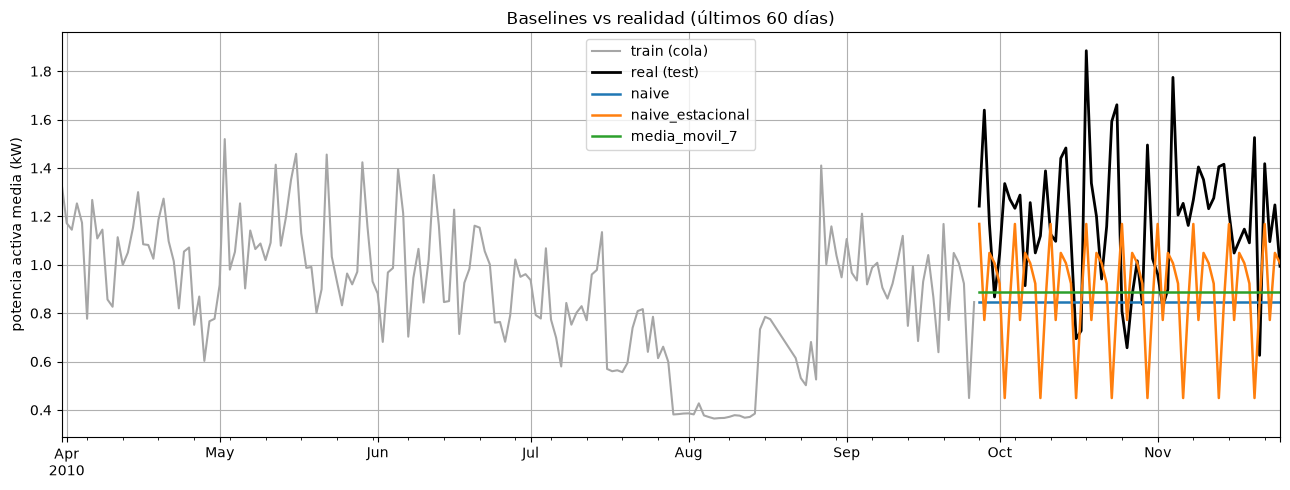

In [25]:
fig = plot_forecast(train, test, baselines,
                    title="Baselines vs realidad (últimos 60 días)")

## 6. Registro en MLflow

Igual que en el Módulo 2, cada modelo (aquí, cada baseline) se registra como
un **run** de MLflow con sus parámetros, sus 5 métricas y la figura del
pronóstico. El backend (`local` con Docker/SQLite o `dagshub` en la nube) se
elige con `MLFLOW_BACKEND` en el archivo `.env` — ver `test_env.example`.

In [26]:
setup_mlflow("module3-01-decomposition", backend="dagshub")

for name, fc in baselines.items():
    log_and_register(
        run_name=f"baseline-{name}",
        params={"model": name, "horizon_days": H, "dataset": "uci-household-power"},
        metrics=all_metrics[name],
        tags={"notebook": "01_decomposition", "familia": "baseline"},
        figures={"plots/forecast.png": fig},
    )
print("Baselines registrados. Revisa la UI de MLflow para compararlos.")

[mlflow_helpers] Backend      : local
[mlflow_helpers] Tracking URI : sqlite:////Users/miguelarquezabdala/repos/dsrp-machine-learning-engineering-20262/module3-time-series/notebooks/mlruns.db
[mlflow_helpers] Experiment   : module3-01-decomposition
Baselines registrados. Revisa la UI de MLflow para compararlos.


## Resumen

- El dataset del módulo: **consumo eléctrico de un hogar** (UCI #235), con
  estacionalidad **anual, semanal e intradía** — trabajamos con la serie
  diaria (modelo **aditivo**: la amplitud no escala con el nivel).
- `seasonal_decompose` es simple pero rígida; **STL** permite estacionalidad
  que evoluciona y es **robusta** a atípicos.
- **Estacionariedad** = media/varianza/autocovarianza constantes; se
  diagnostica con estadísticos móviles + ACF/PACF + **ADF**, y se consigue
  diferenciando: $(1-L)$, $(1-L^7)$.
- Definimos las métricas del módulo (**MSE, RMSE, MAE, MAPE, sMAPE**) y
  fijamos los **baselines** a vencer, registrados en **MLflow**.

Siguiente: **02 — Suavizamiento exponencial y ARIMA/SARIMA**.